# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama               | NRP        |
|--------------------|------------|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [253]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import RobustScaler


In [254]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


### 1.1 Drop kolom Id untuk melihat data duplikat

In [255]:
if 'Id' in data.columns:
    data = data.drop(columns=['Id'])

print(data.columns)
print("Jumlah Missing Values per Kolom")
print(data.isnull().sum())

print("\nJumlah Data Duplikat", data.duplicated().sum())

data = data.drop_duplicates()
print("\nJumlah Data Duplikat Sekarang", data.duplicated().sum())


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')
Jumlah Missing Values per Kolom
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Jumlah Data Duplikat 125

Jumlah Data Duplikat Sekarang 0


### 1.2 Analisis Bivariat

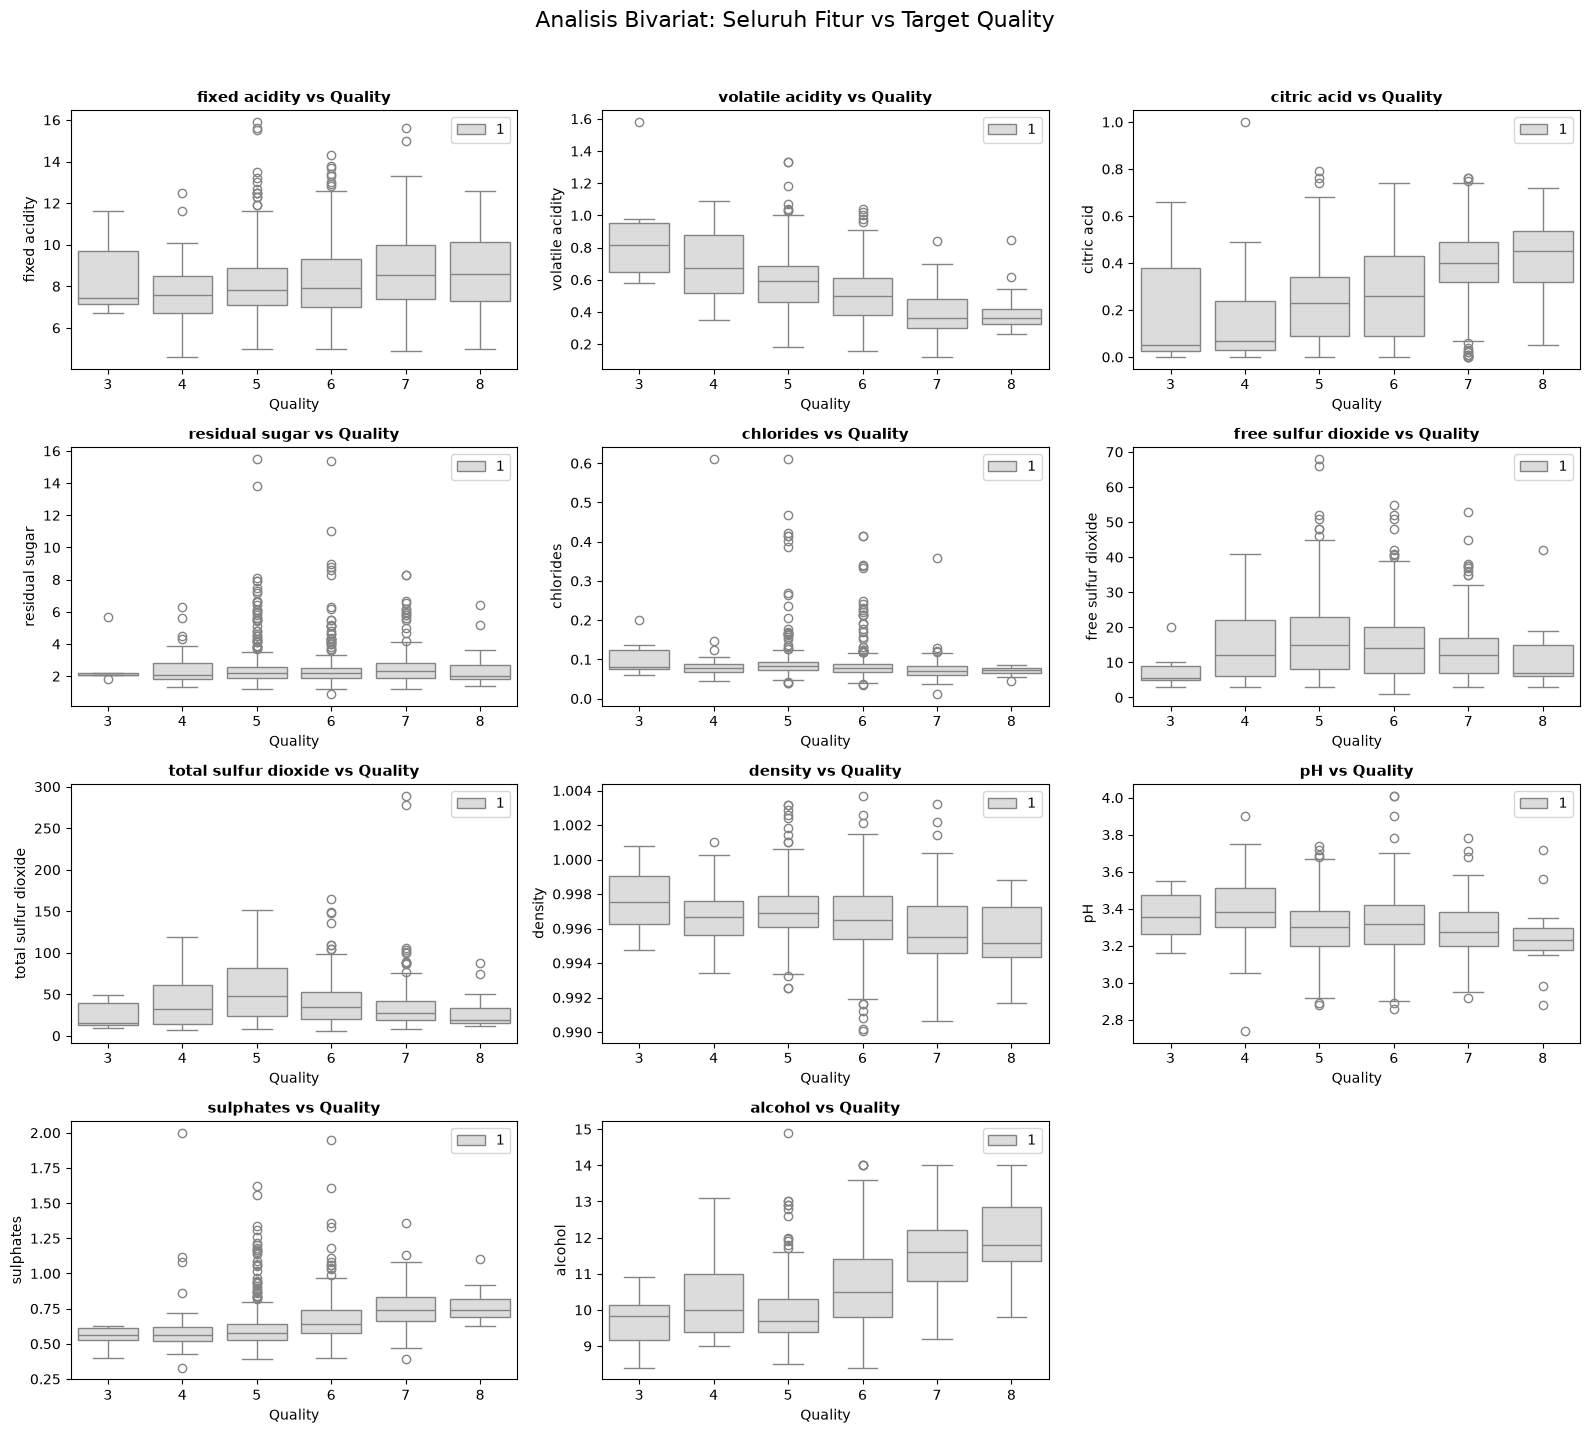

In [256]:
# Daftar semua fitur (kecuali 'Id' dan 'quality')
features = [col for col in data.columns if col not in ['Id', 'quality']]

# Buat Grid Plot Bivariat (Boxplot per Quality)
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=data, x='quality', y=col, ax=axes[i], palette='coolwarm', hue=1)
    axes[i].set_title(f'{col} vs Quality', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(col)

# Hapus subplot sisa jika ada
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Analisis Bivariat: Seluruh Fitur vs Target Quality', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 1.3 Cek Distribusi Label Target Class

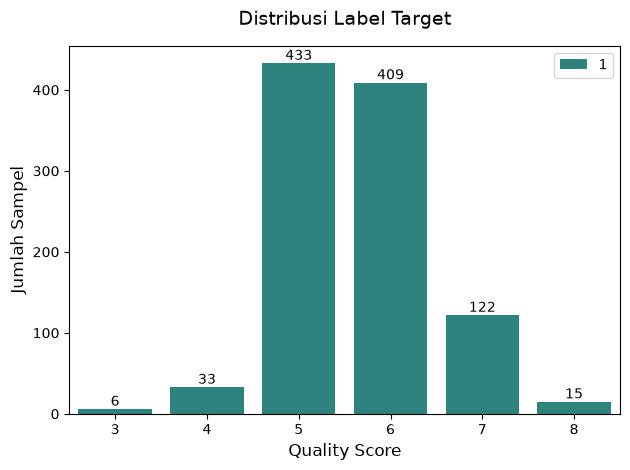

In [257]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

ax = sns.countplot(
    data=data,
    x='quality',
    palette='viridis',
    hue=1
)
ax.bar_label(ax.containers[0])

plt.title("Distribusi Label Target", fontsize=14, pad=15)
plt.xlabel("Quality Score", fontsize=12)
plt.ylabel("Jumlah Sampel", fontsize=12)

plt.tight_layout()
plt.show()

### 1.4 Cek Distribusi Fitur

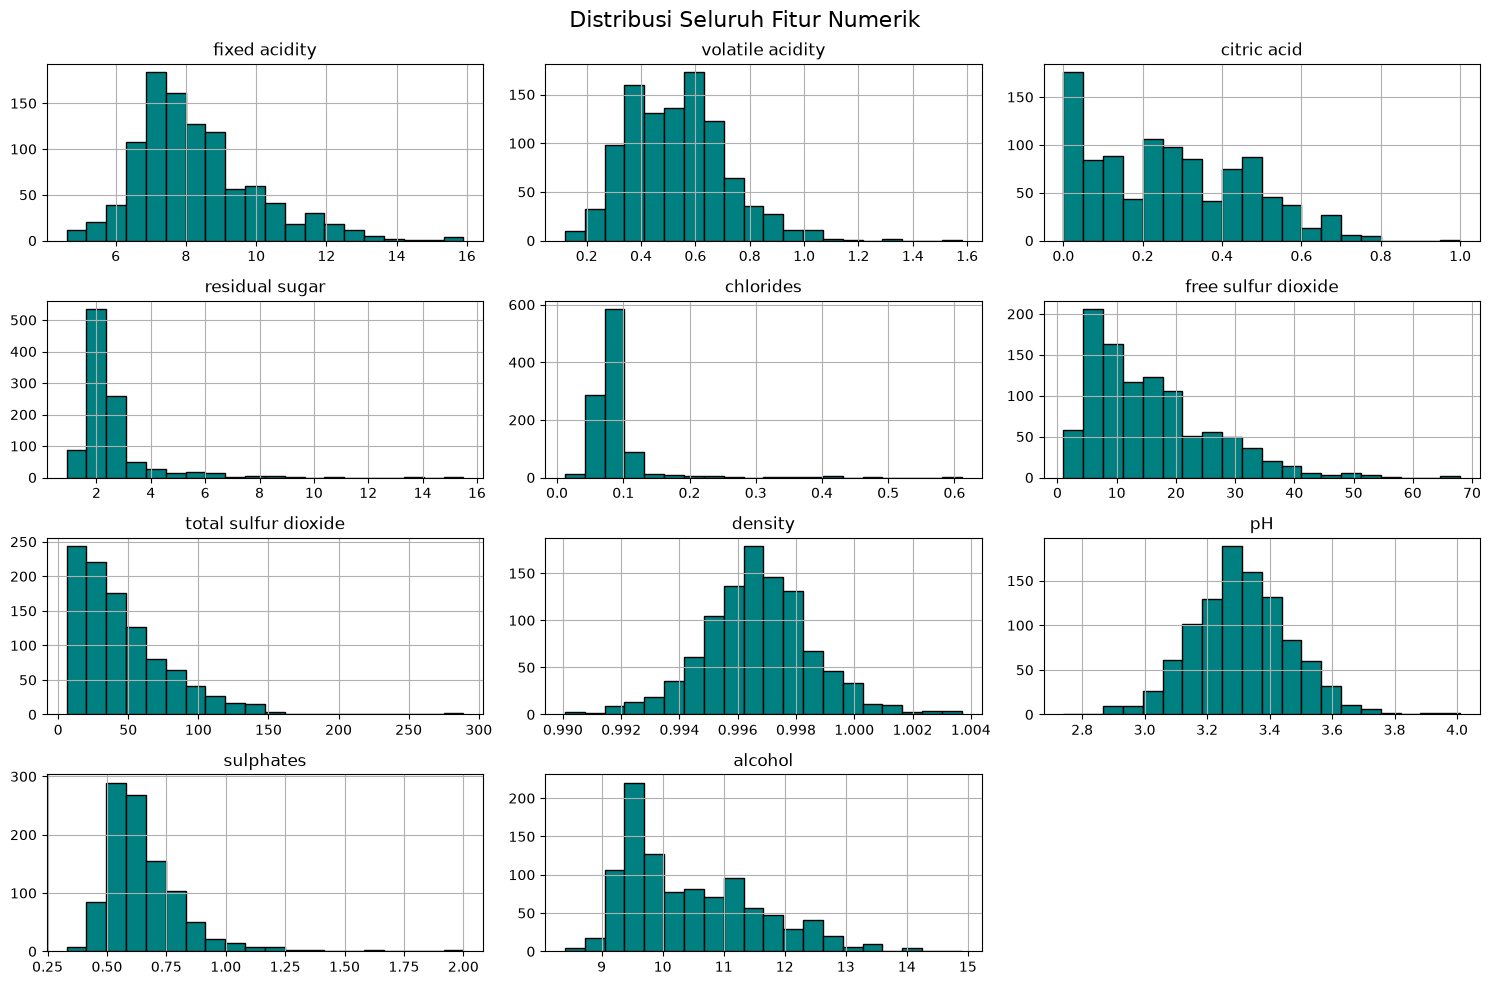

In [258]:
# Distribusi Seluruh Fitur Numerik
data.drop(columns=['Id','quality'],errors='ignore').hist(figsize=(15,10), bins=20, color="teal", edgecolor="black")
plt.suptitle('Distribusi Seluruh Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

### 1.5 Melihat Correlation Matrix

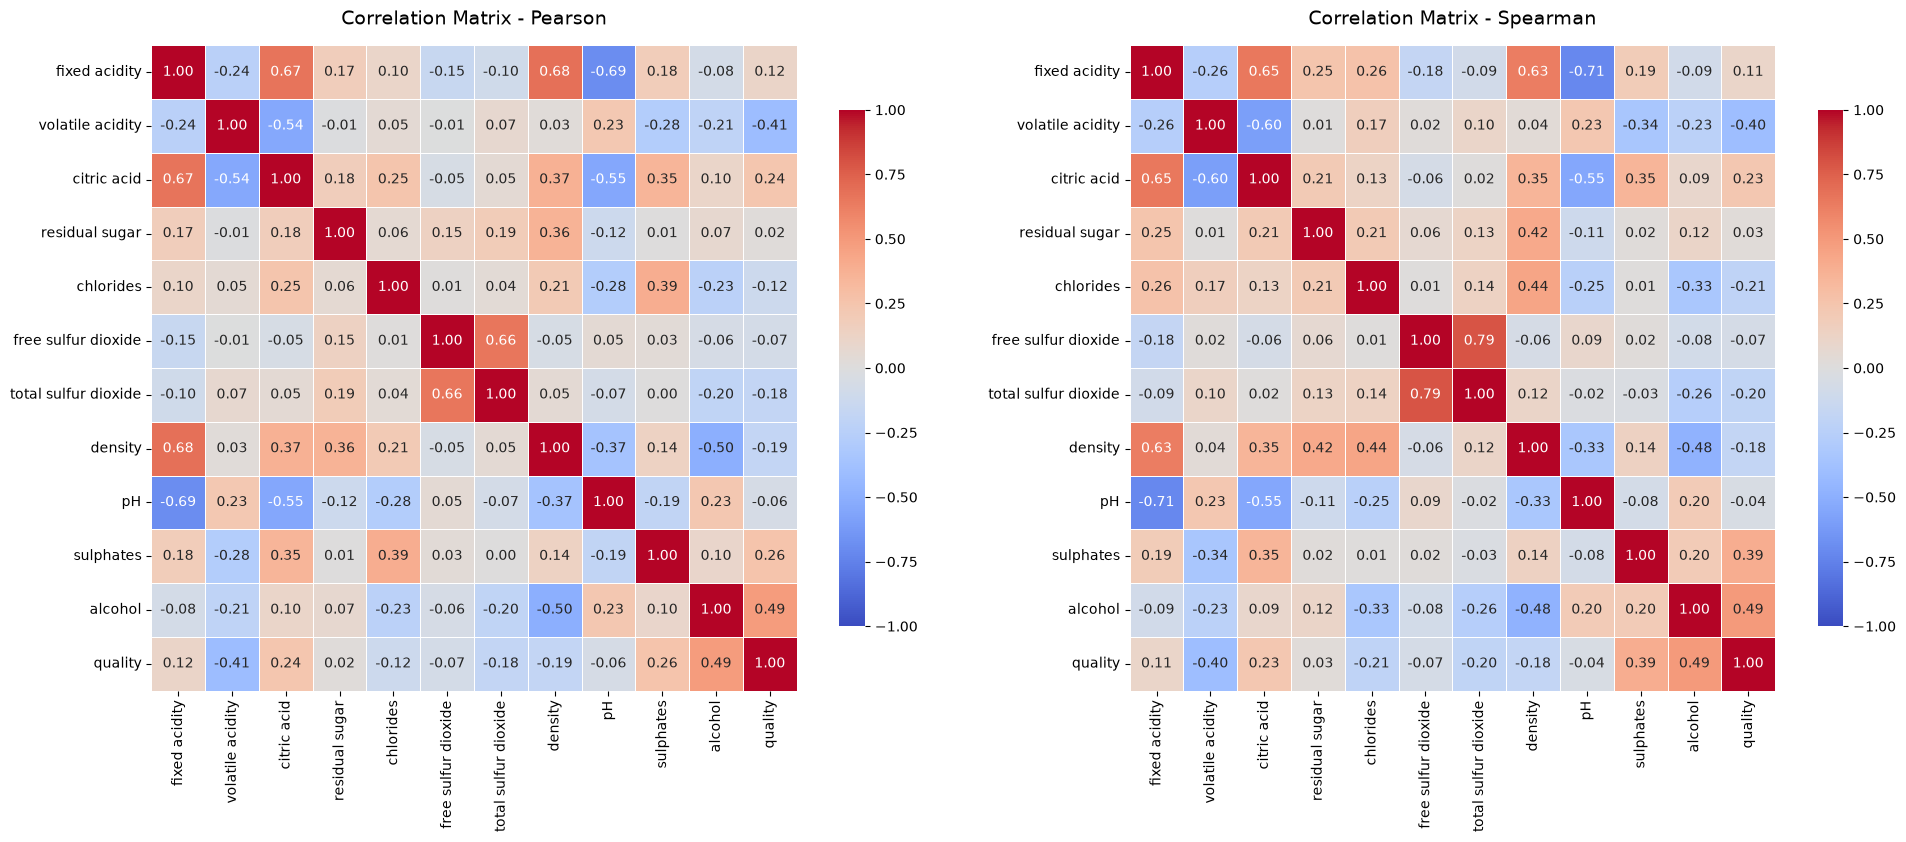

In [259]:
corr = data.corr(numeric_only=True, method="pearson")
corr_spearman = data.corr(numeric_only=True, method="spearman")
fig, axes = plt.subplots(1,2, figsize=(20,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=axes[0]
)
axes[0].set_title('Correlation Matrix - Pearson', fontsize=14, pad=15)

sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    center=0,
    square=True,
    cbar_kws={'shrink' : 0.8},
    ax=axes[1]
)
axes[1].set_title('Correlation Matrix - Spearman', fontsize=14, pad=15)

plt.tight_layout()
plt.show()


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




### 2.1 Periksa Outlier

In [260]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
features = [col for col in data.columns if col not in ['Id', 'quality']]

outlier_summary = []

for col in features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1-1.5 * IQR
    upper_bound = Q3+1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(data)) * 100

    outlier_summary.append({
        'Fitur': col,
        'Q1 (25%)': round(Q1, 3),
        'Q3 (75%)': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Batas Bawah': round(lower_bound, 3),
        'Batas Atas': round(upper_bound, 3),
        'Jumlah Outlier': count,
        'Persentase (%)': round(percentage, 2)
    })

df_outlier_summary = pd.DataFrame(outlier_summary)
print(df_outlier_summary.to_string(index=False))

               Fitur  Q1 (25%)  Q3 (75%)    IQR  Batas Bawah  Batas Atas  Jumlah Outlier  Persentase (%)
       fixed acidity     7.100     9.100  2.000        4.100      12.100              37            3.63
    volatile acidity     0.390     0.645  0.255        0.008       1.028              10            0.98
         citric acid     0.090     0.420  0.330       -0.405       0.915               1            0.10
      residual sugar     1.900     2.600  0.700        0.850       3.650              95            9.33
           chlorides     0.070     0.090  0.020        0.040       0.120              71            6.97
 free sulfur dioxide     7.000    21.000 14.000      -14.000      42.000              16            1.57
total sulfur dioxide    21.000    62.000 41.000      -40.500     123.500              33            3.24
             density     0.996     0.998  0.002        0.992       1.001              30            2.95
                  pH     3.210     3.400  0.190        

### 2.2 Cek berapa baris yang mempunyai outlier

In [261]:
# Cek baris mana saja yang punya minimal 1 outlier di fitur manapun
has_outlier = pd.Series(False, index=data.index)

for col in features:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    has_outlier = has_outlier | (data[col] < lower_bound) | (data[col] > upper_bound)

total_outliers = has_outlier.sum()
print(f"Total baris yang memiliki minimal 1 outlier : {total_outliers} baris dari {len(data)} data")
print(f"Persentase data terdampak outlier           : {round(total_outliers / len(data) * 100, 2)}%")


Total baris yang memiliki minimal 1 outlier : 262 baris dari 1018 data
Persentase data terdampak outlier           : 25.74%


### 2.3 Capping Outlier berbasis IQR

In [262]:
# Fungsi Capping Outlier berbasis IQR (Hanya menghitung statistik batas dari X_train)
def cap_outliers_split(X_train, X_test, columns):
    X_train_capped = X_train.copy()
    X_test_capped = X_test.copy()
    
    for col in columns:
        # Hitung Q1, Q3, dan IQR HANYA dari data Train (agar tidak data leakage)
        Q1 = X_train_capped[col].quantile(0.25)
        Q3 = X_train_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Batas ditentukan DARI X_TRAIN, lalu diterapkan ke X_train & X_test
        X_train_capped[col] = np.where(X_train_capped[col] < lower_bound, lower_bound, X_train_capped[col])
        X_train_capped[col] = np.where(X_train_capped[col] > upper_bound, upper_bound, X_train_capped[col])
        
        X_test_capped[col] = np.where(X_test_capped[col] < lower_bound, lower_bound, X_test_capped[col])
        X_test_capped[col] = np.where(X_test_capped[col] > upper_bound, upper_bound, X_test_capped[col])
        
    return X_train_capped, X_test_capped

print("Fungsi Capping Outlier siap digunakan!")



Fungsi Capping Outlier siap digunakan!


### 2.4  Features Dropping

In [263]:
features_to_drop = ['residual sugar', 'free sulfur dioxide', 'pH']

X = data.drop(columns=['quality'] + features_to_drop)
y = data['quality']

print("Ukuran Matriks Fitur (X) :", X.shape)
print("Ukuran Vektor Target (y) :", y.shape)

print("Daftar Fitur yang Digunakan Sekarang:")
print(X.columns.tolist())
print(f"Jumlah Fitur Sekarang: {X.shape[1]} fitur (dari awal 11 fitur)")


Ukuran Matriks Fitur (X) : (1018, 8)
Ukuran Vektor Target (y) : (1018,)
Daftar Fitur yang Digunakan Sekarang:
['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'sulphates', 'alcohol']
Jumlah Fitur Sekarang: 8 fitur (dari awal 11 fitur)


### 2.5 Memisahkan data train dan test

--- Hasil Pembagian Data & Capping ---
Jumlah Data Latih (X_train_capped) : 814 baris
Jumlah Data Uji   (X_test_capped)  : 204 baris


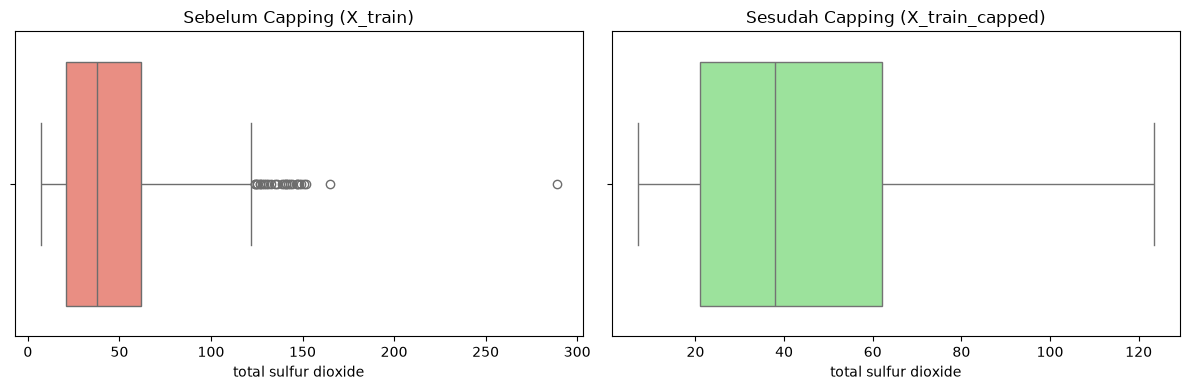

In [264]:
# 1. Train-Test Split terlebih dahulu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 2. Terapkan Capping Outlier setelah Split
X_train_capped, X_test_capped = cap_outliers_split(X_train, X_test, X_train.columns)

print("--- Hasil Pembagian Data & Capping ---")
print("Jumlah Data Latih (X_train_capped) :", X_train_capped.shape[0], "baris")
print("Jumlah Data Uji   (X_test_capped)  :", X_test_capped.shape[0], "baris")

# 3. Visualisasi Boxplot Sebelum vs Sesudah Capping pada Data Train
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=X_train, x='total sulfur dioxide', ax=axes[0], color='salmon')
axes[0].set_title("Sebelum Capping (X_train)")
sns.boxplot(data=X_train_capped, x='total sulfur dioxide', ax=axes[1], color='lightgreen')
axes[1].set_title("Sesudah Capping (X_train_capped)")
plt.tight_layout()
plt.show()


### 2.6 Scaling data

In [265]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_capped)
X_test_scaled = scaler.transform(X_test_capped)

print("Feature Scaling Berhasil!")
print("Ukuran X_train_scaled :", X_train_scaled.shape)
print("Ukuran X_test_scaled  :", X_test_scaled.shape)

Feature Scaling Berhasil!
Ukuran X_train_scaled : (814, 8)
Ukuran X_test_scaled  : (204, 8)


# 3. Eksperimen Model KNN


In [266]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

k_values = [3,5,7,9,11]
metrics = ['euclidean', 'manhattan']
weights_list = ['uniform', 'distance']

experiment_results = []

for weight in weights_list:
    for metric in metrics:
        for k in k_values:
            # Model KNN dengan parameter weights
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weight)
            knn.fit(X_train_scaled, y_train)
            
            y_train_pred = knn.predict(X_train_scaled)
            y_test_pred = knn.predict(X_test_scaled)
            
            train_acc = accuracy_score(y_train, y_train_pred)
            test_acc = accuracy_score(y_test, y_test_pred)
            
            experiment_results.append({
                'Weights': weight,
                'Metrik Jarak': metric.capitalize(),
                'Nilai K': k,
                'Akurasi Train (%)': round(train_acc * 100, 2),
                'Akurasi Test (%)': round(test_acc * 100, 2)
            })

df_results = pd.DataFrame(experiment_results)
print("=== HASIL EKSPERIMEN MODEL KNN ===")
print(df_results.to_string(index=False))

=== HASIL EKSPERIMEN MODEL KNN ===
 Weights Metrik Jarak  Nilai K  Akurasi Train (%)  Akurasi Test (%)
 uniform    Euclidean        3              73.10             51.47
 uniform    Euclidean        5              67.44             58.33
 uniform    Euclidean        7              65.97             58.82
 uniform    Euclidean        9              65.72             57.35
 uniform    Euclidean       11              65.23             56.37
 uniform    Manhattan        3              74.20             50.98
 uniform    Manhattan        5              69.78             55.88
 uniform    Manhattan        7              67.20             62.75
 uniform    Manhattan        9              64.37             57.84
 uniform    Manhattan       11              64.74             59.80
distance    Euclidean        3             100.00             54.41
distance    Euclidean        5             100.00             55.88
distance    Euclidean        7             100.00             55.39
distance    E

# 4. Evaluasi Model


=== CLASSIFICATION REPORT (MODEL TERBAIK) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.14      0.20         7
           5       0.69      0.76      0.72        87
           6       0.60      0.61      0.61        82
           7       0.50      0.46      0.48        24
           8       0.00      0.00      0.00         3

    accuracy                           0.63       204
   macro avg       0.35      0.33      0.33       204
weighted avg       0.61      0.63      0.61       204



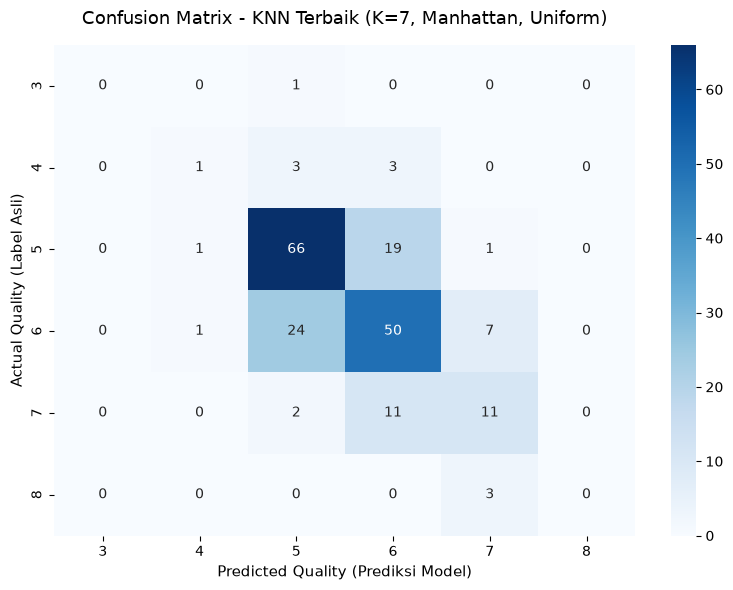

In [267]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# 1. Melatih Model KNN Terbaik (K=7, Manhattan, Uniform)
best_knn = KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='uniform')
best_knn.fit(X_train_scaled, y_train)

# 2. Prediksi Data Test
y_pred_best = best_knn.predict(X_test_scaled)

# 3. Cetak Classification Report
print("=== CLASSIFICATION REPORT (MODEL TERBAIK) ===")
print(classification_report(y_test, y_pred_best, zero_division=0))

# 4. Plot Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title('Confusion Matrix - KNN Terbaik (K=7, Manhattan, Uniform)', fontsize=13, pad=15)
plt.xlabel('Predicted Quality (Prediksi Model)', fontsize=11)
plt.ylabel('Actual Quality (Label Asli)', fontsize=11)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

### A. Analisis Dampak Preprocessing & Pembersihan Data
1. **Penanganan Duplikat & Outlier**:
   - Setelah membuang kolom Id yang tidak relevan, ditemukan **125 data duplikat** sehingga total data bersih menjadi **1.018 baris**.
   - Penanganan outlier dilakukan menggunakan metode **Capping** daripada menghapus data. Metode ini mengatasi outlier yang berlebih dan kurang dengan cara di press ke titik maksimal dan minmal tanpa membuang satu pun data, sehingga sampel kualitas yang dikit kaya (quality 3 dan 8) tidak makin berkurang.

2. **Feature Selection**:
   - Pada eksperimen awal menggunakan seluruh 11 fitur, akurasi tertinggi model KNN berada di angka **59,31%**.
   - Setelah menganalisis matriks korelasi dan membuang 3 fitur yang kurang berpengaruh seperti(residual sugar, free sulfur dioxide, dan pH), akurasi model KNN berhasil **meningkat secara signifikan menjadi 62.75%**.

3. **Feature Scaling**:
   - Penggunaan StandardScaler sangat krusial karena algoritma KNN berbasis perhitungan jarak (Euclidean/Manhattan). Tanpa scaling, fitur ber-skala besar seperti total sulfur dioxide akan mendominasi 99% perhitungan jarak.
   - Penggunaan stratify=y pada train_test_split (80:20) berhasil menjaga agar rasio distribusi kelas quality pada Data Train dan Data Test tetap seimbang sesuai dataset asli.

---

### B. Analisis Performa Model KNN & Parameter Terbaik
Berdasarkan eksperimen kombinasi hiperparameter (Nilai K, Metrik Jarak, dan *Weights*), diperoleh temuan berikut:

- **Model Terbaik**: 
  - **Nilai K**: 7
  - **Metrik Jarak**: Manhattan (Jarak L1)
  - **Skema Bobot**: Uniform
  - **Akurasi Uji (Test Accuracy)**: **62.75%**

### C. Analisis Confusion Matrix
Dari visualisasi Confusion Matrix 6x6 dan Classification Report pada data uji:
1. **Konsentrasi Prediksi Benar**: Tebakan benar model (diagonal utama) sangat dominan pada kelas quality **5** dan **6**, karena kedua kelas ini memiliki jumlah sampel paling banyak.
2. **Kelemahan pada class yang datanya sedikit**: Kategori quality 3 dan 8 memiliki nilai *Recall* yang rendah karena jumlah sampelnya pada data train sangat sedikit (*Class Imbalance*).


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### A. Kesimpulan
1. **Model Terbaik**: KNN terbaik dicapai pada konfigurasi **K = 7**, metrik **Manhattan**, dan bobot **Uniform**, dengan akurasi uji sebesar **62,75%**.
2. **Dampak Preprocessing**:
   - Men-drop 3 fitur noise (residual sugar, free sulfur dioxide, pH) sukses menaikkan akurasi dari **59,31% menjadi 62,75%**.
   - Metode **Capping (Winsorization)** berhasil menetralkan outlier tanpa membuang satu pun baris data.
3. **Performa**: Akurasi 62,75% sudah sangat baik untuk klasifikasi 6 kelas (jauh di atas tebakan acak 16,67%).

### B. Saran
1. **Coba Target Binning**: Mengelompokkan target menjadi 3 kategori (*Low, Medium, High*) agar akurasi bisa naik hingga >80%.
2. **Uji Algoritma Lain**: Membandingkan KNN dengan model seperti **Random Forest** atau **XGBoost**.